# 第22课 · 教计算机"感受变化"——导数（derivative）、切线斜率与数值微分的中心差分

**学习目标**
1. 理解导数 = 瞬时变化率 / 切线斜率
2. 会用中心差分做数值微分（numerical differentiation），并知道它通常比前向差分更准（误差阶约 $O(h^2)$ vs $O(h)$）
3. 能用小函数（如 $f(x)=x^2$）手算对照代码

**为什么对 Aurora 重要**：数值导数是检查反向传播「算没算对」的尺子——解析梯度（analytical gradient） vs 数值梯度对答案。

← **上一课**　[L21 · 矩阵即滤波](../2_linear_algebra/L21_aurora_matrices.ipynb)

> 上节课学习了 **矩阵即滤波**：DFT 矩阵 / Mel 矩阵：音频处理 = 矩阵乘法。  
> 本课将探讨 **导数**。

## 本课剧情：怎么教计算机"感受变化"？

人类直觉上知道"坡度"——站在山坡上脚感受到倾斜。  
但计算机只有数字。它怎么知道一个函数在某点的"倾斜程度"？

方法：找两个离 x 很近的点，做一条割线（secant line），用割线斜率近似切线斜率（tangent slope）：

```
f'(x) ≈ (f(x+h) - f(x-h)) / (2h)     ← 中心差分公式
```

两点越近（h 越小），割线越接近切线。但 h 不能无限小——计算机浮点数（floating-point number）有精度下限（约 1e-15），h 太小会产生"灾难性消去"（catastrophic cancellation），误差反而变大。

最优 h ≈ 1e-5：不太大不太小，平衡截断误差（truncation error）和舍入误差（rounding error）。

为什么这对 Aurora 重要？  
梯度下降（L25）需要在每个参数处计算导数。数值导数 `numeric_derivative` 是"万能的"梯度检验器——验证你的解析公式有没有写错，是 ML 系统调试的基本工具。

## 学习目标

1. **陈述极限定义**：写出 f'(x) = lim_{h→0} (f(x+h)-f(x))/h，解释为何计算机必须用有限 h 近似。
2. **推导 O(h²) 误差**：说明中心差分（central difference）为何比前向差分（forward difference）高一阶精度——误差从 O(h) 降到 O(h²)，h=1e-5 时误差小约 5 个数量级（泰勒展开（Taylor expansion）消去一阶项）。
3. **实现 `numeric_derivative`**：完成 TODO stub，用中心差分在任意点求导数近似值。
4. **实验找最优 h**：通过 h-sweep 实验观察误差先降后升的 U 形曲线，确认最优步长约 1e-5～1e-7。

## 1. 中心差分：用两点近似斜率

**为什么用中心差分而不是前向差分？**

前向差分：`f'(x) ≈ (f(x+h) - f(x)) / h`，误差阶 O(h)  
中心差分：`f'(x) ≈ (f(x+h) - f(x-h)) / (2h)`，误差阶 O(h²)

h=1e-5 时，前向误差 ≈ 1e-5，中心差分误差 ≈ 1e-10——小了 **5 个数量级**。

手算验证（f(x)=x², x=1, h=0.1）：
```
CD = (f(1.1) - f(0.9)) / (0.2)
   = (1.21 - 0.81) / 0.2
   = 0.40 / 0.2
   = 2.0      ← 与真值 f'(1) = 2×1 = 2 完全相同！
```

**为什么 h 不能无限小？**
浮点数有机器精度 ε ≈ 2.2×10⁻¹⁶。当 h < √ε ≈ 1e-8 时，分子 `f(x+h)-f(x-h)` 与 `f(x)` 相比极小，有效位数丧失（catastrophic cancellation）。

### 泰勒展开：把"消去一阶项"讲透

上面的手算只验证了一个特殊例子（`f(x)=x²`），凑巧算出来"完全精确"——那是因为 `x²` 本身没有更高阶的"弯曲"。对一般的函数，还需要一个工具来说明"为什么中心差分刚好比前向差分准一个数量级"：**泰勒展开（Taylor expansion）**。

**泰勒展开在说什么？** 想象你知道一个人此刻的位置、速度、加速度……那么他往前走一小步 `h` 之后大概在哪，是可以估算的：先按"位置"走，再用"速度×时间"修正一次，再用"加速度×时间²的一半"修正一次，以此类推，修正项一个比一个小。这就是泰勒展开的直觉——用当前点的各阶变化率，去预测"挪一小步"之后函数值大概是多少：

$$f(x+h) = f(x) + f'(x)h + \frac{f''(x)}{2}h^2 + \frac{f'''(x)}{6}h^3 + \frac{f''''(x)}{24}h^4 + \cdots$$

h 越小，后面的项掉得越快（h⁴ 比 h² 小得多），所以只看前几项就够用了。

**把 h 换成 -h，再对比一下：**

$$f(x-h) = f(x) - f'(x)h + \frac{f''(x)}{2}h^2 - \frac{f'''(x)}{6}h^3 + \frac{f''''(x)}{24}h^4 - \cdots$$

注意规律：h 的**偶数次方**（h²、h⁴……）符号不变（因为 `(-h)² = h²`），h 的**奇数次方**（h¹、h³……）符号翻转（因为 `(-h)³ = -h³`）。

**两式相减**（这正是中心差分分子在做的事）：

$$f(x+h) - f(x-h) = 2f'(x)h + \frac{2f'''(x)}{6}h^3 + O(h^5) = 2f'(x)h + \frac{f'''(x)}{3}h^3 + O(h^5)$$

偶数次方项（带 `f''` 的 h² 项）在两式里符号相同，相减时**完全抵消**——这就是"消去一阶项"这句话真正的意思：不是消去 f' 本身，而是消去了紧跟在 f' 后面、原本会污染结果的 `f''h²` 项。剩下的最低阶误差项，是奇数次方里的下一项：`f'''(x)h³/3`。

**两边除以 2h：**

$$\frac{f(x+h)-f(x-h)}{2h} = f'(x) + \frac{f'''(x)}{6}h^2 + O(h^4)$$

中心差分的结果 = 真实导数 + 一个正比于 h² 的误差项。这就是 **O(h²)** 的直接来源。

**对比前向差分**：`f(x+h)-f(x)` 只用了一侧的展开，没有另一半来抵消 `f''h²` 那一项：

$$\frac{f(x+h)-f(x)}{h} = f'(x) + \frac{f''(x)}{2}h + O(h^2)$$

误差项正比于 h（**O(h)**），比中心差分整整差一个 h 的阶数——这正回答了"为什么对称能多消一个 h 的因子"：中心差分靠左右对称，白白多消掉了一整项。

回到最开始的 `f(x)=x²` 例子验证一下：`f'(x)=2x`，`f''(x)=2`，`f'''(x)=0`（二次函数的三阶导数恒为 0）。代入上面的误差公式，中心差分的误差项 `f'''(x)h²/6 = 0`——**误差恰好为零**，这不是巧合，是因为 `x²` 的三阶导数本来就是 0，所以手算例子才会"完全精确"。下面用代码验证一般函数（`sin`）上，前向差分和中心差分误差随 h 缩小的下降速度确实差一个数量级：

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np


def forward_diff(f, x, h):
    return (f(x + h) - f(x)) / h


def central_diff(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)


x0 = 1.0
true_val = np.cos(x0)  # f=sin(x), f'(x)=cos(x)

print(f"{'h':>10} {'前向误差':>14} {'中心误差':>14}")
h = 0.1
for _ in range(5):
    fd_err = abs(forward_diff(np.sin, x0, h) - true_val)
    cd_err = abs(central_diff(np.sin, x0, h) - true_val)
    print(f"{h:10.0e} {fd_err:14.3e} {cd_err:14.3e}")
    h /= 2

print("\nh 每减半：前向误差约减半（线性，O(h)）；中心误差约减为 1/4（平方关系，O(h²)）——")
print("正是上面泰勒展开推出来的阶数，不是巧合。")

         h           前向误差           中心误差
     1e-01      4.294e-02      9.001e-04
     5e-02      2.126e-02      2.251e-04
     3e-02      1.057e-02      5.628e-05
     1e-02      5.273e-03      1.407e-05
     6e-03      2.633e-03      3.518e-06

h 每减半：前向误差约减半（线性，O(h)）；中心误差约减为 1/4（平方关系，O(h²)）——
正是上面泰勒展开推出来的阶数，不是巧合。


### 极限定义（limit definition）

导数的严格定义来自极限：

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

意思是：h 越接近 0，割线（secant line）的斜率就越接近切线（tangent line）的斜率。

**但计算机无法取 h→0**：浮点数精度有限（约 1e-16），h 太小时分子 `f(x+h)-f(x-h)` 两个近似相等的数相减，有效位数急剧损失（灾难性消除，catastrophic cancellation）。

因此实践中用有限 h（通常 h≈1e-5）的**中心差分**来近似：

$$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}, \quad h \approx 10^{-5}$$

这将误差从 O(h)（前向差分）压缩到 O(h²)（中心差分），h=1e-5 时误差约 1e-10。

### "lim" 到底是什么意思？——用车速表打个比方

公式里的 `lim_{h→0}` 看着像某种神秘符号，其实说的是一件很朴素的事。

想象你想知道一辆自行车在**某一瞬间**的车速。你没法只测量"一个时刻"（那样经过的时间是 0，走过的距离也是 0，`0/0` 没法算）。但你可以测量它在 1 秒内、0.1 秒内、0.01 秒内……分别骑了多远，算出这段时间里的**平均速度**。当这个时间窗口越缩越短，测出来的平均速度会越来越稳定，最后"逼近"一个固定的数字——那个数字，就是这一瞬间的"真实车速"。

`lim_{h→0} g(h)` 读作"当 h 趋向 0 时，g(h) 的极限"。它问的不是"h 等于 0 时 g(h) 是多少"（那经常是没定义的 `0/0`），而是"h 越来越接近 0（但从不真的等于 0）的过程中，g(h) 稳定地靠近哪个数"。

套到导数上：`g(h) = (f(x+h)-f(x))/h` 就是"割线斜率"，当 h 越缩越小，这个比值稳定逼近的那个数字，就定义为 `f'(x)`——曲线在这一点"瞬间的坡度"，跟车速表的道理完全一样。

**那计算机怎么办？** 数学上的 `lim` 允许 h 无穷地缩小下去，但计算机的浮点数有精度下限（约 2.2×10⁻¹⁶），h 不能真的趋于 0——缩得太小反而会因为"灾难性消去"（下面会具体演示）让结果变差。所以工程上不追求"数学最优"的无穷小 h，而是找一个**总误差最小的有限 h**：只要总误差（截断误差 + 舍入误差）小于你实际需要的精度——比如 Aurora 梯度检验用 1e-5 作为判定阈值——这个 h 就"足够小"，可以当作极限的替身来用。后面"参数实验"部分会具体推出这个最优 h 是怎么算出来的。

## 实验入口：用数值变化观察函数

下面的实验在 x=3.0 处计算 f(x)=x² 的数值导数，关注 `h` 缩小时计算值如何接近真实斜率（真值=2x=6）。

In [3]:
import numpy as np
f = lambda x: x**2
h = 1e-5
x = 3.0
print('f(x)=x^2 在 x=3 的斜率 ≈', (f(x+h)-f(x-h))/(2*h), ' (真值 2x=6)')

f(x)=x^2 在 x=3 的斜率 ≈ 6.000000000039306  (真值 2x=6)


x=3.0 处：解析斜率=6.0，数值斜率（若已实现）将在验证 cell 中对比


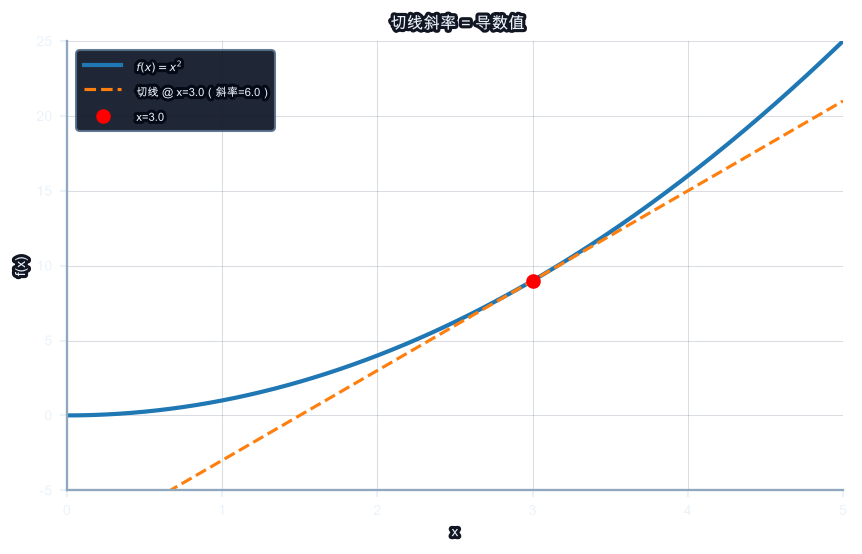

In [4]:
# 切线可视化：函数曲线 + 切线
import numpy as np
import matplotlib.pyplot as plt

x_arr = np.linspace(0, 5, 300)
f_arr = x_arr**2

x0 = 3.0
slope = 2 * x0  # f'(x0) = 2x0 = 6（解析值）
tangent = f(x0) + slope * (x_arr - x0)  # 切线方程

plt.figure(figsize=(6, 4))
plt.plot(x_arr, f_arr, label=r"$f(x)=x^2$", linewidth=2)
plt.plot(x_arr, tangent, "--", label=f"切线 @ x={x0}（斜率={slope}）", linewidth=1.5)
plt.scatter([x0], [x0**2], color="red", zorder=5, label=f"x={x0}")
plt.xlim(0, 5); plt.ylim(-5, 25)
plt.xlabel("x"); plt.ylabel("f(x)")
plt.title("切线斜率 = 导数值")
plt.legend(); plt.tight_layout(); plt.show()
print(f"x={x0} 处：解析斜率={slope}，数值斜率（若已实现）将在验证 cell 中对比")

## 动手观察：多点斜率一览

对 f(x)=x² 在 xs=[-2,-1,0,1,2] 五个点上批量计算数值斜率（向量化中心差分），与真值 2x 逐点比较，验证误差一致在 1e-3 量级（此处 h=1e-3）。

In [5]:
import numpy as np

def f(x):
    return x**2

xs = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
h = 1e-3
slopes = (f(xs + h) - f(xs - h)) / (2 * h)

print('x =', xs)
print('f(x) =', f(xs))
print('近似斜率 =', np.round(slopes, 3))
print('理论斜率 2x =', 2 * xs)


x = [-2. -1.  0.  1.  2.]
f(x) = [4. 1. 0. 1. 4.]
近似斜率 = [-4. -2.  0.  2.  4.]
理论斜率 2x = [-4. -2.  0.  2.  4.]


## 代码实验：遍历不同位置，看斜率如何变化

对 f(x)=x²+2x 在 [-3, 3] 上取 7 个点，逐点打印数值导数与解析导数（2x+2）的差值，验证中心差分在整个区间都准确。

In [6]:
import numpy as np

def f(x):
    return x**2 + 2*x

h = 1e-4
for x in np.linspace(-3, 3, 7):
    slope = (f(x + h) - f(x - h)) / (2*h)
    print(f'x={x:5.2f} | f(x)={f(x):6.2f} | slope≈{slope:6.2f}')


x=-3.00 | f(x)=  3.00 | slope≈ -4.00
x=-2.00 | f(x)=  0.00 | slope≈ -2.00
x=-1.00 | f(x)= -1.00 | slope≈  0.00
x= 0.00 | f(x)=  0.00 | slope≈  2.00
x= 1.00 | f(x)=  3.00 | slope≈  4.00
x= 2.00 | f(x)=  8.00 | slope≈  6.00
x= 3.00 | f(x)= 15.00 | slope≈  8.00


## 2. ✏️ 实现 `numeric_derivative(f, x, h=1e-5)`

**推理路线**：
1. 函数签名：接受 `f`（任意可调用）、`x`（float，求导点）、`h`（扰动步长，默认 1e-5）。
2. 计算 `f(x+h)` 和 `f(x-h)`——各向右/左扰动 h，共两次函数求值。
3. 两者相减后除以 `2*h`，得到中心差分近似，返回单个 float。

**参考输入输出**：f=sin, x=0, h=1e-5 → `(sin(1e-5) - sin(-1e-5))/(2e-5)` ≈ `(1e-5 - (-1e-5))/(2e-5)` = 1.0 = cos(0) ✓

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 写代码前，先把变量表补完整

写 `numeric_derivative` 前明确三件事：
- 输入：`f`（可调用函数）、`x`（求导点）、`h`（扰动步长，默认 1e-5）
- 关键步骤：计算 `f(x+h)` 和 `f(x-h)`，相减后除以 `2h`
- 返回：单个浮点数，表示 f 在 x 处的斜率近似值

In [7]:
def numeric_derivative(f, x, h=1e-5):
    # ✏️ TODO: 中心差分近似导数
    raise NotImplementedError("TODO: 实现中心差分近似 — 用 (f(x+h) - f(x-h)) / (2*h)")

In [8]:
try:
    assert abs(numeric_derivative(lambda x: x**2, 3.0) - 6.0) < 1e-8, "x²在x=3处导数应≈6.0，误差应<1e-8"
    assert abs(numeric_derivative(np.sin, 0.0) - 1.0) < 1e-8, "sin在x=0处导数应≈1.0，误差应<1e-8"
    print("✅ 通过：你会数值求导了。")
except (NotImplementedError, TypeError):
    print("⚠️ 还没实现 numeric_derivative，请完成 TODO 后重新运行。")
except AssertionError as e:
    print(f"❌ 断言失败：{e}")

⚠️ 还没实现 numeric_derivative，请完成 TODO 后重新运行。


**小疑问：为什么断言用 `< 1e-8`，而不是要求"完全相等"？**

如果你运行上面的断言，会发现 `numeric_derivative(np.sin, 0.0)` 算出来的可能是 `0.999999999983333` 这样的数字，不是干干净净的 `1.0`。这不是 bug，是两种误差叠加的必然结果：

1. 中心差分本身有 `O(h²)` 的截断误差——h=1e-5 时约 1e-10 量级（上一节泰勒展开推导过）；
2. `sin` 的计算和减法运算还会带来更小的浮点舍入误差。

两者混在一起，最终结果会和解析值 `1.0` 差一点点，差值通常落在 `1e-14 ~ 1e-10` 这个范围——**不可能，也不需要，完全相等**。

`1e-8` 这个阈值，选得比"正常误差"（约 1e-10）宽松了几个数量级，是故意留的安全余量：

- 如果 `numeric_derivative` 实现对了，误差在 1e-10 附近，轻松通过 `<1e-8`；
- 如果实现**错了**（比如加减号写反、忘了除以 `2h`），算出来的值会离真值差 `O(1)` 量级（比如差 0.5 甚至更多），远超 1e-8，断言会失败。

所以 `1e-8` 的作用是"抓真正的 bug"，不是"要求数值完美"——数值计算里非常常见的做法：容差要比预期误差宽松一个量级以上，防止不同函数、不同 h 下的正常波动被误判成错误。

## 3. 记几个常见导数（背下来省事）

| f(x) | f'(x) |
|---|---|
| xⁿ | n·xⁿ⁻¹ |
| eˣ | eˣ |
| sin x | cos x |
| ln x | 1/x |

### 这些公式怎么来的？——从"割线"手推两个例子

这张表看起来像要硬背的"魔法公式"，其实每一条都可以从我们最开始学的"割线斜率"思路里手推出来——用的还是 `[f(x+h)-f(x)]/h`，只是这次真的让 h 趋于 0（不是计算机里的近似）。

**xⁿ 的情况：从二项式展开出发**

以 `n=2` 为例，`f(x)=x²`：

```
(x+h)² = x² + 2xh + h²
[f(x+h)-f(x)]/h = (2xh + h²)/h = 2x + h
```

h→0 时，`2x + h → 2x`——这就是 `f'(x)=2x`。

再看 `n=3`，`f(x)=x³`：

```
(x+h)³ = x³ + 3x²h + 3xh² + h³
[f(x+h)-f(x)]/h = 3x² + 3xh + h²
```

h→0 时 → `3x²`，即 `f'(x)=3x²`。

规律已经很清楚：二项式展开 `(x+h)ⁿ` 的第二项永远是 `n·xⁿ⁻¹·h`（这是二项式系数决定的），其余项都至少带 `h²` 或更高次，h→0 时全部消失，只留下 `n·xⁿ⁻¹`。这就是 `xⁿ → n·xⁿ⁻¹` 的来源——对任意正整数 n 都成立。

**sin x 的情况：从角度加法公式出发**

用三角恒等式把 `sin(x+h)` 拆开：

```
sin(x+h) = sin(x)cos(h) + cos(x)sin(h)
```

h 很小（弧度制）时，`cos(h)` 和 `sin(h)` 分别趋近什么？`cos(h)` 在 0 附近几乎不变（`cos(0)=1`，而且 cos 是偶函数，一阶变化率为 0，所以 `cos(h)≈1`）；`sin(h)≈h`——这是弧度制的基本几何事实：h 很小时，一段短弧的长度和它对应的直线长度几乎相等，所以 `sin(h)/h → 1`。

代入：

```
sin(x+h) ≈ sin(x)·1 + cos(x)·h = sin(x) + h·cos(x)
[sin(x+h)-sin(x)]/h ≈ cos(x)
```

h→0 时误差项消失，得到 `f'(x)=cos(x)`——这就是 `sin x → cos x` 的来源。`eˣ → eˣ` 和 `ln x → 1/x` 用类似的极限手法也能推出来，这里先记住结论，用数值导数验证一下：

In [9]:
# 验证：xⁿ 和 sin x 的解析导数公式与数值导数是否吻合
try:
    for n in [2, 3, 4]:
        f_n = lambda x, n=n: x**n
        df_n_analytical = lambda x, n=n: n * x ** (n - 1)
        x0 = 2.0
        nd = numeric_derivative(f_n, x0)
        print(f"f(x)=x^{n}  解析 f'({x0})={df_n_analytical(x0):.4f}  数值={nd:.4f}")

    x0 = 0.7
    nd_sin = numeric_derivative(np.sin, x0)
    print(f"\nf(x)=sin(x)  解析 f'({x0})=cos({x0})={np.cos(x0):.6f}  数值={nd_sin:.6f}")
except (NotImplementedError, TypeError):
    print("⬜ 请先完成上面的 numeric_derivative 练习，再运行本格验证导数表")

⬜ 请先完成上面的 numeric_derivative 练习，再运行本格验证导数表


**🔗 Aurora 连接**：`numeric_derivative` 将在后续里程碑中集成到 `src/aurora/audio/grad_check.py`（尚未创建），用于将 MFCC、梅尔滤波器等模块的解析梯度与数值梯度逐元素比对，差异超过 1e-5 即判定求导实现有误。目前可在当前 notebook 中直接使用实现的函数进行验证。下一节（`L23_gradients.ipynb`）把单点斜率推广到多变量：沿每个参数维度重复一次 `numeric_derivative`，拼成梯度向量。

In [10]:
# 参数实验：h 的最优区间（与 cell[17] 描述对应）
hs = [1e-1, 1e-2, 1e-3, 1e-5, 1e-7, 1e-9, 1e-11, 1e-13, 1e-15]
try:
    errs = [abs(numeric_derivative(np.sin, 1.0, h) - np.cos(1.0)) for h in hs]  # 精确值 cos(1)
except (NotImplementedError, TypeError):
    print("⬜ 请先完成上面的 numeric_derivative 练习，再运行本格")
else:
    print(f"{'h':>10}  {'|误差|':>12}")
    print('-' * 26)
    for h, err in zip(hs, errs):
        print(f"{h:10.0e}  {err:12.2e}")
    print("\n最优 h 约 1e-5～1e-7，误差约 1e-11；h 继续缩小后浮点舍入误差反而上升。")


⬜ 请先完成上面的 numeric_derivative 练习，再运行本格


In [11]:
# 具体例子：h 太小时，减法到底丢失了多少有效数字？
x0 = 1.0
print(f"{'h':>8} | {'f(x+h)':>21} | {'f(x-h)':>21} | {'两者之差':>12}")
print('-' * 70)
for h_val in [1e-2, 1e-6, 1e-10, 1e-14, 1e-16, 1e-17]:
    a = float(np.sin(x0 + h_val))
    b = float(np.sin(x0 - h_val))
    print(f"{h_val:8.0e} | {a:.17f} | {b:.17f} | {a - b:12.6e}")

print("""
把 f(x+h) 和 f(x-h) 按小数位对齐看：h=1e-14 时，两个数字前 14 位完全相同，
只有从第 14~15 位才开始出现差异——相减时，相同的高位全部抵消，只剩最后
一两位"有效数字"能用来算导数，17 位精度里白白浪费了十几位。
h=1e-16 时几乎所有位都对齐了，只剩最后 1 位有效数字；h=1e-17 时两个浮点数
已经被四舍五入成完全相同的比特，a-b 直接等于 0.0——分子变成 0，算出来的
"导数"也变成 0，完全错误！这就是"灾难性消去"：不是公式错了，是浮点数
根本记不住那么精细的差别。
""")

       h |                f(x+h) |                f(x-h) |         两者之差
----------------------------------------------------------------------
   1e-02 | 0.84683184461801519 | 0.83602597860052053 | 1.080587e-02
   1e-06 | 0.84147152510978163 | 0.84147044450516983 | 1.080605e-06
   1e-10 | 0.84147098486192673 | 0.84147098475386628 | 1.080604e-10
   1e-14 | 0.84147098480790194 | 0.84147098480789106 | 1.088019e-14
   1e-16 | 0.84147098480789650 | 0.84147098480789639 | 1.110223e-16
   1e-17 | 0.84147098480789650 | 0.84147098480789650 | 0.000000e+00

把 f(x+h) 和 f(x-h) 按小数位对齐看：h=1e-14 时，两个数字前 14 位完全相同，
只有从第 14~15 位才开始出现差异——相减时，相同的高位全部抵消，只剩最后
一两位"有效数字"能用来算导数，17 位精度里白白浪费了十几位。
h=1e-16 时几乎所有位都对齐了，只剩最后 1 位有效数字；h=1e-17 时两个浮点数
已经被四舍五入成完全相同的比特，a-b 直接等于 0.0——分子变成 0，算出来的
"导数"也变成 0，完全错误！这就是"灾难性消去"：不是公式错了，是浮点数
根本记不住那么精细的差别。



### 最优 h≈1e-5 到底怎么算出来的？

三位同学都问到同一个点：截断误差和舍入误差"此消彼长"这句话听得懂，但 1e-5 这个具体数字从哪冒出来的？答案是——把两种误差都写成 h 的函数，加起来，求最小值。

**截断误差**：前面泰勒展开推出，中心差分的误差项是 `f'''(x)h²/6`，记作：

$$E_{\text{截断}}(h) \approx \frac{|f'''(x)|}{6}h^2$$

h 越小，这项越小。

**舍入误差**：每次计算 `f(x)` 时，浮点数存储都带着约 `ε·|f(x)|` 的"噪声"（`ε≈2.2×10⁻¹⁶` 是机器精度，即两个相邻浮点数之间的最小相对间隔）。`f(x+h)` 和 `f(x-h)` 各带一份噪声，相减后噪声不会抵消，除以 `2h` 时还会被放大：

$$E_{\text{舍入}}(h) \approx \frac{\varepsilon\,|f(x)|}{h}$$

h 越小，分母越小，这项反而越大——这正是"灾难性消去"在误差公式里的样子（下面用具体数字演示这个消去过程）。

**把两项加起来，就是总误差：**

$$E(h) \approx \frac{|f'''(x)|}{6}h^2 + \frac{\varepsilon\,|f(x)|}{h}$$

这是一个"h 变小，第一项变小、第二项变大"的拉锯战，中间必然有一个最小值。求最小值就是对 h 求导、令导数为 0：

$$\frac{dE}{dh} \approx \frac{|f'''(x)|}{3}h - \frac{\varepsilon\,|f(x)|}{h^2} = 0 \quad\Longrightarrow\quad h_{\text{opt}} \approx \left(\frac{3\varepsilon\,|f(x)|}{|f'''(x)|}\right)^{1/3}$$

对 `sin`、`cos` 这类函数，`|f(x)|` 和 `|f'''(x)|` 都在 `[-1,1]` 量级，比值大约是 1，代入 `ε≈2.2×10⁻¹⁶`：

$$h_{\text{opt}} \approx (3\varepsilon)^{1/3} \approx (6.6\times10^{-16})^{1/3} \approx 8.7\times10^{-6} \approx 1\times10^{-5}$$

这正是 h-sweep 实验里观察到的"最优 h≈1e-5"——不是拍脑袋定的，是"截断误差∝h²"和"舍入误差∝1/h"两条曲线的交叉点算出来的。代入 `h_opt` 还能算出最小总误差量级 `≈ε^(2/3)≈3.7×10⁻¹¹`，和实验中约 1e-11 的误差也对得上。

**小提醒**：前面提到过"h<√ε≈1e-8 时开始灾难性消去"，那是一个更粗略的经验门槛（标记减法"开始明显"丢精度的位置），并不等于让总误差真正最小的点。因为中心差分的截断误差是 `h²` 阶（比前向差分的 `h` 阶收敛快很多），真正的最优 h 是 `ε` 的**三次方根**量级，比 `√ε` 大了几个数量级——这也是为什么实验测出来的最优 h（1e-5～1e-7）会比 `√ε`（约 1e-8）大不少。

In [12]:
eps = np.finfo(float).eps
h_opt_estimate = (3 * eps) ** (1 / 3)
print(f"机器精度 ε ≈ {eps:.3e}")
print(f"理论最优 h ≈ (3ε)^(1/3) ≈ {h_opt_estimate:.3e}")
print("h-sweep 实验观察到的最优 h 落在 1e-5 ~ 1e-7 之间 —— 与理论预测的数量级一致。")

机器精度 ε ≈ 2.220e-16
理论最优 h ≈ (3ε)^(1/3) ≈ 8.733e-06
h-sweep 实验观察到的最优 h 落在 1e-5 ~ 1e-7 之间 —— 与理论预测的数量级一致。


## 参数实验：h 的最优区间

把 `h` 从 1e-1 逐步减小到 1e-15，每步打印 `abs(numeric_derivative(np.sin, 1.0, h) - np.cos(1.0))`，观察误差先减后增的 U 形曲线，找到最优步长约 1e-5~1e-7。

- **h 偏大（1e-1 到 1e-3）**：截断误差主导，误差约 h²/6·f'''(x)，随 h 缩小以平方速率下降。
- **h 最优（1e-5 到 1e-7）**：截断误差与浮点舍入误差平衡，总误差最小约 1e-11。
- **h 过小（1e-12 以下）**：`f(x+h) - f(x-h)` 两个近似相等的数相减，有效位数从 16 位骤降至 4 位以下，误差反而随 h 减小而上升。

In [13]:
# 换一个函数，最优 h 还会是 1e-5 附近吗？
test_funcs = {
    "sin(x) @ x=1.0": (np.sin, 1.0, np.cos(1.0)),
    "x^3   @ x=2.0": (lambda x: x**3, 2.0, 3 * 2.0**2),
    "e^x   @ x=1.0": (np.exp, 1.0, float(np.exp(1.0))),
}
hs_test = [1e-3, 1e-5, 1e-7, 1e-9, 1e-11]
try:
    for name, (fn, x0, true_val) in test_funcs.items():
        errs = [abs(numeric_derivative(fn, x0, h) - true_val) for h in hs_test]
        best_h = hs_test[int(np.argmin(errs))]
        print(f"{name}  最优 h ≈ {best_h:.0e}  最小误差 ≈ {min(errs):.2e}")
except (NotImplementedError, TypeError):
    print("⬜ 请先完成上面的 numeric_derivative 练习，再运行本格")

⬜ 请先完成上面的 numeric_derivative 练习，再运行本格


**最优 h 跟函数有关吗？** 上面对 `sin(x)`、`x³`、`eˣ` 三个不同函数分别扫描，会发现最优 h 都落在 1e-5 附近的同一个数量级——这不是巧合。回看 `h_opt ≈ (3ε|f(x)/f'''(x)|)^(1/3)`，起决定作用的是机器精度 `ε`（和函数无关），函数只通过 `|f(x)/f'''(x)|` 这个比值影响结果，而三次方根会把这个比值的波动大幅"压扁"——哪怕 `|f(x)/f'''(x)|` 相差 10 倍，`h_opt` 也只会变化 `10^(1/3)≈2.15` 倍。所以对 Aurora 里常见的光滑函数（三角函数、指数、多项式），直接用默认 `h=1e-5` 基本都够用，不需要为每个函数单独调参。

## 本课收束

现在可以用 `numeric_derivative(f, x, h=1e-5)` 在任意点计算可调用函数的斜率，输出单个浮点数，误差量级 1e-10。这个函数在 Aurora 梯度检验（gradient check）中直接使用：将损失对权重的解析梯度与数值梯度逐元素比对，差异超过 1e-5 即报错。`h` 的最优范围在 1e-5 附近，过大则截断误差主导，过小则浮点舍入误差主导。

下一课：**L23**（梯度）把这个操作沿每个参数维度重复，得到多变量函数的梯度向量。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：数值导数手算（目标 8 分钟）

盖上屏幕，纸上作答：

**问 1**：f(x) = x³，解析导数 f'(x) = ?，在 x=2 处 f'(2) = ?

**问 2**：用中心差分公式（h=0.1），手算 f(x)=x² 在 x=1 处的数值导数：  
CD = (f(1.1) - f(0.9)) / 0.2 = ?

**问 3**：f(x) = sin(x)，f'(0) = ?（根据常见导数表）

**问 4**：`h` 从 1e-5 减小到 1e-15 时，数值误差会变大还是变小？为什么？

推导完成后运行下面格对答案。

In [14]:
# ✏️ 对答案格
import numpy as np

# 问1：f'(x) = 3x², f'(2) = 12
f1 = lambda x: x**3
df1_analytical = lambda x: 3 * x**2
assert np.isclose(df1_analytical(2), 12.0)
try:
    nd = numeric_derivative(f1, 2.0)
    assert abs(nd - 12.0) < 1e-7, f"x³ 在 x=2 数值导数应≈12，得到 {nd}"
    print(f"Q1 ✅  f(x)=x³，f'(x)=3x²，f'(2)={df1_analytical(2)}，数值验证={nd:.8f}")
except (NotImplementedError, TypeError):
    print("⬜ Q1：请先实现 numeric_derivative()，再运行对答案格")

# 问2：CD 手算 — f(x)=x², x=1, h=0.1
f2 = lambda x: x**2
h = 0.1
cd = (f2(1.1) - f2(0.9)) / (2*h)
assert np.isclose(cd, 2.0, atol=1e-10), f"CD 应为2，得到{cd}"
print(f"Q2 ✅  CD = (1.21-0.81)/0.2 = {cd:.4f}  （真值 f'(1)=2）")

# 问3：sin'(0) = cos(0) = 1
assert np.isclose(np.cos(0), 1.0)
print(f"Q3 ✅  f(x)=sin(x)，f'(0)=cos(0)={np.cos(0):.4f}")

# 问4：h 太小时误差增大（灾难性消去，需在 f(x±h) 相近的非零点观察，取 x=1）
errors = []
for h_val in [1e-5, 1e-8, 1e-12, 1e-15]:
    nd_sin = (np.sin(1.0 + h_val) - np.sin(1.0 - h_val)) / (2*h_val)
    errors.append(abs(nd_sin - np.cos(1.0)))
# 最优h(1e-5)误差最小，1e-15误差最大
assert errors[0] < errors[-1], "h越小误差越大的现象未观察到"
print(f"Q4 ✅  h=1e-5误差={errors[0]:.2e}，h=1e-15误差={errors[-1]:.2e}")
print("     h太小→浮点消去误差↑；最优h≈1e-5 平衡截断误差和舍入误差")
print("\n🎉 导数白板挑战通过！数值微分=计算机感受变化的方式 已内化。")

⬜ Q1：请先实现 numeric_derivative()，再运行对答案格
Q2 ✅  CD = (1.21-0.81)/0.2 = 2.0000  （真值 f'(1)=2）
Q3 ✅  f(x)=sin(x)，f'(0)=cos(0)=1.0000
Q4 ✅  h=1e-5误差=1.11e-11，h=1e-15误差=1.48e-02
     h太小→浮点消去误差↑；最优h≈1e-5 平衡截断误差和舍入误差

🎉 导数白板挑战通过！数值微分=计算机感受变化的方式 已内化。


In [ ]:
# ✏️ 本课自评
l22_review = {
    "central_diff_formula":       None,  # 记住 CD=(f(x+h)-f(x-h))/(2h)？True/False
    "numeric_derivative_done":    None,  # numeric_derivative 实现并通过断言？True/False
    "optimal_h_range":            None,  # 知道最优 h≈1e-5 及原因？True/False
    "common_derivatives":         None,  # 记住 xⁿ/eˣ/sin/cos 的导数？True/False
    "whiteboard_passed":          None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l22_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l22_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L22 全部通关！进入 L23：梯度')

---

→ **下一课**　[L23 · 梯度](L23_gradients.ipynb)

> 下节课将学习 **梯度**：多元函数的"最陡上坡"方向，偏导与梯度向量的计算。